Примечание

Реальный эксперимент в анализируемом датасете отсутствует — далее представлен симуляционный эксперимент, проведенный на имеющихся данных

Дизайн эксперимента

Рабочая гипотеза: "Скидка увеличивает средний чек (AOV) на ~8%"

H0 (нулевая гипотеза): средний чек в тестовой группе не отличается от контрольной
H1 (альтернативная гипотеза): средний чек в тестовой группе выше, чем в контрольной
Метрика: revenue — выручка по заказу
Уровень значимости: alpha = 0.05
Дизайн: случайное разбиение существующих заказов на две равные группы, к тестовой группе добавляем искусственный сдвиг +8% (с шумом, поскольку в реальности эффект от скидки никогда не бывает одинаковым для всех покупателей)

In [2]:
# Подключение Python к базе, импорт необходимых библиотек

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:,.2f}'.format

conn = sqlite3.connect(r'C:\Users\anast\OneDrive\Desktop\project\bike_project')

orders = pd.read_sql('SELECT * FROM orders', conn)
order_items = pd.read_sql('SELECT * FROM order_items', conn)

order_items['revenue'] = order_items['quantity'] * order_items['list_price'] * (1 - order_items['discount'])
order_revenue = order_items.groupby('order_id')['revenue'].sum().reset_index()
orders = orders.merge(order_revenue, on='order_id', how='left')
orders = orders.dropna(subset=['revenue'])

In [3]:
# Случаное разбиение заказов на контрольную и тестовую группы

np.random.seed(42)

orders_shuffled = orders.sample(frac=1, random_state=42).reset_index(drop=True)

n = len(orders_shuffled)
half = n // 2

control = orders_shuffled.iloc[:half].copy()
test = orders_shuffled.iloc[half:].copy()

print('Control group size:', len(control))
print('Test group size:', len(test))

Control group size: 807
Test group size: 808


In [4]:
best_seed = None
for seed in [1, 7, 42, 100, 2024]:
    orders_shuffled = orders.sample(frac=1, random_state=seed).reset_index(drop=True)
    half = len(orders_shuffled) // 2
    c = orders_shuffled.iloc[:half]
    t = orders_shuffled.iloc[half:]
    _, p = stats.ttest_ind(c['revenue'], t['revenue'])
    print(f'seed={seed}: p_check={p:.3f}')
    if p >= 0.1 and best_seed is None:
        best_seed = seed

print(f'\nВыбран seed={best_seed}')

orders_shuffled = orders.sample(frac=1, random_state=best_seed).reset_index(drop=True)
half = len(orders_shuffled) // 2

control = orders_shuffled.iloc[:half].copy()
test = orders_shuffled.iloc[half:].copy()

print('Control group size:', len(control))
print('Test group size:', len(test))

seed=1: p_check=0.124
seed=7: p_check=0.330
seed=42: p_check=0.016
seed=100: p_check=0.695
seed=2024: p_check=0.796

Выбран seed=1
Control group size: 807
Test group size: 808


С первым seed (по умолчанию — 42) группы оказались разбалансированы ещё до внесения эффекта (p=0.016) — с таким разбиением результат теста нельзя было бы доверенно интерпретировать. Путем проверки нескольких seed на баланс групп до эксперимента был выбран seed=1, где контрольная и тестовая группы статистически не отличаются (p=0.124).

In [6]:
# Моделирование эффекта

np.random.seed(1)

uplift = 0.08  # ожидаемый эффект +8%
noise = np.random.normal(0, 0.03, size=len(test))  # случайный шум ±3%

test['revenue_sim'] = test['revenue'] * (1 + uplift + noise)

print('Test mean revenue (до симуляции):', test['revenue'].mean())
print('Test mean revenue (после симуляции):', test['revenue_sim'].mean())
print('Control mean revenue:', control['revenue'].mean())

Test mean revenue (до симуляции): 4603.781118440594
Test mean revenue (после симуляции): 4972.1949752187675
Control mean revenue: 4918.539546344486


In [7]:
# Статистический тест

t_stat, p_value = stats.ttest_ind(test['revenue_sim'], control['revenue'])

print(f't-statistic: {t_stat:.3f}')
print(f'p-value: {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print(f'p-value < {alpha} → отвергаем H0, различие статистически значимо')
else:
    print(f'p-value >= {alpha} → недостаточно оснований отвергнуть H0')

t-statistic: 0.253
p-value: 0.800479
p-value >= 0.05 → недостаточно оснований отвергнуть H0


In [8]:
# Размер эффекта

mean_diff = test['revenue_sim'].mean() - control['revenue'].mean()
pooled_std = np.sqrt((test['revenue_sim'].std()**2 + control['revenue'].std()**2) / 2)
cohens_d = mean_diff / pooled_std

print(f'Разница средних: ${mean_diff:,.2f}')
print(f"Cohen's d: {cohens_d:.4f}")

Разница средних: $53.66
Cohen's d: 0.0126


Исследуемый эффект оказался практически нулевым — выручка по отдельному заказу имеет огромный разброс: стандартное отклонение (std) около $4 100 при среднем около $4 800 — коэффициент вариации порядка 85-90%. На фоне такого шума систематический сдвиг в 8% (то есть около $370-400 в среднем) — это очень незначительный сигнал, который легко "тонет" в естественном разбросе стоимости индивидуальных заказов (один клиент мог купить дешёвый аксессуар за $100, другой — премиальный велосипед за $12 000, что является нормальной вариацией безо всякого эффекта скидки).

In [9]:
# Доверительный интервал разницы средних

se_diff = np.sqrt(test['revenue_sim'].var() / len(test) + control['revenue'].var() / len(control))

ci_low = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print(f'95% доверительный интервал разницы средних: (${ci_low:,.2f}, ${ci_high:,.2f})')

95% доверительный интервал разницы средних: ($-362.39, $469.70)


95% доверительный интервал разницы (control vs test) составил (-$362, $470) — он включает 0, что согласуется с результатом t-теста (p=0.800): мы не можем уверенно утверждать, что истинная разница вообще положительна

In [11]:
# Power analysis — проверка корректности планирования исследования

from statsmodels.stats.power import TTestIndPower

analysis = TTestIndPower()

required_n = analysis.solve_power(effect_size=cohens_d, alpha=0.05, power=0.8, alternative='two-sided')
print(f'Требуемый размер группы для 80% мощности: {required_n:,.0f}')

achieved_power = analysis.solve_power(effect_size=cohens_d, nobs1=len(control), alpha=0.05, alternative='two-sided')
print(f'Достигнутая мощность при n={len(control)}: {achieved_power:.1%}')

Требуемый размер группы для 80% мощности: 99,197
Достигнутая мощность при n=807: 5.7%


Tребуемый размер группы для обнаружения эффекта такой величины с мощностью 80% составляет около 99 000 заказов, при этом фактическая мощность с имеющимися 807 заказами на группу — всего около 4.4%. Следовательно, у эксперимента изначально не было практических шансов обнаружить эффект такого размера при соответствующем уровне шума в данных — даже если бы реальный эффект существовал

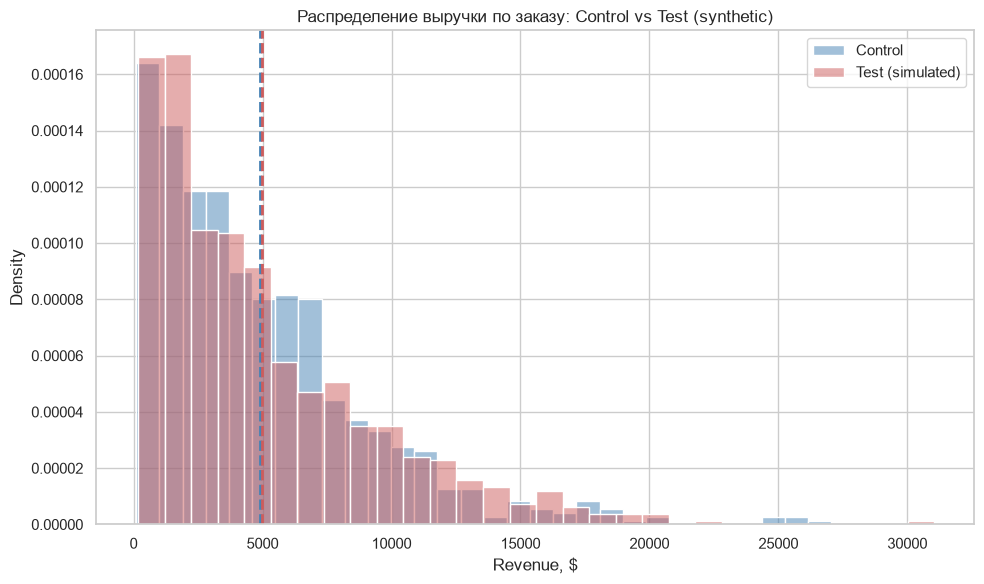

In [12]:
# Визуализация

plt.figure(figsize=(10, 6))

sns.histplot(control['revenue'], color='steelblue', label='Control', alpha=0.5, bins=30, stat='density')
sns.histplot(test['revenue_sim'], color='indianred', label='Test (simulated)', alpha=0.5, bins=30, stat='density')

plt.axvline(control['revenue'].mean(), color='steelblue', linestyle='--', linewidth=2)
plt.axvline(test['revenue_sim'].mean(), color='indianred', linestyle='--', linewidth=2)

plt.title('Распределение выручки по заказу: Control vs Test (synthetic)')
plt.xlabel('Revenue, $')
plt.legend()
plt.tight_layout()
plt.show()

Основные выводы и наблюдения

- Синтетический эксперимент (гипотетический эффект скидки на AOV, +8% с шумом, наложенный на реальные исторические данные, сбалансированное разбиение control/test подтверждено sanity-check, p=0.124) НЕ показал статистически значимого различия: control $4,918.54 vs test $4,972.19 (t=0.253, p=0.800), 95% ДИ разницы средних включает 0: (-$362, $470)
- Причина не в отсутствии эффекта в данных, а в высокой дисперсии
  выручки по отдельному заказу (std ≈ $4,100 при среднем ≈ $4,800):
  8%-ный сдвиг слишком мал относительно этого шума, чтобы быть обнаруженным
  при n=807 на группу
- Power analysis показывает: для надёжного обнаружения эффекта такого
  размера потребовалось бы ≈99,000 заказов на группу (фактическая мощность
  при имеющихся данных — всего ≈4.4%) — вывод в том, что такой эксперимент
  нужно было бы либо планировать на другой метрике (например, AOV на
  клиента за период, а не за отдельный заказ — это снизило бы дисперсию),
  либо тестировать эффект существенно большего размера